# Multimodal AutoML LOOCV — SC + FC + MSN  [따로 예측한 뒤 예측값을 평균 (late fusion) · pass]

세 모달리티(SC, FC, MSN)를 한 예측에 쓰는 방법 다섯 가지 중 **방법 D**다. 방법마다 노트북을 따로 만들었다.
뼈대(6개 모델 · LOOCV · nested GridSearchCV · fold 안에서 residualize)는 `multimodal_sc_fc84/`, `multimodal_msn_fc68/` 노트북과 같다.

## 이 노트북의 방법

피처를 붙이지 않는다. `SC PCA3 + FC PCA3` 모델과 `MSN–FC coupling ROI 4개` 모델을 **따로 학습**하고,
빠진 한 사람에 대한 **두 예측값을 평균**한다 (같은 종류의 모델끼리, 가중치 없이 1:1).
피처 수가 늘지 않아 과적합 부담이 없고, 평균에는 학습할 것이 없어 추가 탐색도 없다.

## 데이터 / 표본

- `../sc_dk84/sc_strength_84_pass.csv` (SC strength 84, 모델에 넣을 때 log(1 + count)), `../fc_strength_68_16.csv` (FC strength 84), `../msn_strength_68.csv` (MSN strength, 피질 68)
- `../msn_full_68x68.csv`, `../fc_full_68x68.csv` (edge 2278개씩) → MSN–FC coupling 계산에만 사용
- SC 45명 ∩ FC 44명 ∩ MSN 45명 = **공통 44명** (sub-001은 FC 없음). 타겟 `vas_t1`, 임상 `vas_t0` + `treatment_group`.
- nuisance (fold 안 train에서만 fit): SC와 MSN은 age, sex, eTIV / FC는 age, sex, mean_fd / coupling은 age, sex, eTIV, mean_fd

## 피처셋 (Clinical 2개는 항상 포함)

| Data Type | 내용 |
|---|---|
| `Clinical_ONLY` | 뇌 피처 없음 |
| `SC_FC_PCA3` | SC PCA3 + FC84 PCA3 (6개)로 학습한 모델 |
| `MSNFC_Coup_ROI4` | MSN–FC coupling(Spearman) ROI 4개로 학습한 모델 |
| `Tri_LateAvg` | **위 두 모델의 예측값 평균** (모델 종류별로 따로 평균) |

PCA 성분 수 3은 모든 블록에서 같고, 기존 노트북과 맞춘 값이다.

## 연결 기준: **pass** — streamline이 두 영역을 모두 지나가면 연결로 센다 (DSI Studio 기본값). **주 분석**

SC는 "무엇을 연결로 세느냐"에 따라 값이 크게 달라진다. 같은 사람들로 구한 영역별 coupling의 pass와 end 사이
상관이 0.525였다. 그래서 같은 분석을 두 기준으로 따로 만들었고(`..._pass.ipynb`, `..._end.ipynb`),
**주 분석은 pass, end는 민감도 분석**으로 결과를 보기 전에 정해 두었다. 어느 쪽이 좋게 나오든 둘 다 보고한다.

## 읽을 때 주의

- **결과를 본 뒤에 정한 조합이다.** SC + FC(end)와 MSN–FC ROI coupling이 좋게 나온 것을 확인한 다음 만들었다.
  방법 다섯 가지를 미리 정해 두고 pass, end를 전부 보고한다. 탐색적 결과로 읽는다.
- 잔차화 직전에 nuisance를 train 기준으로 표준화한다. 잔차는 수학적으로 같고, eTIV(백만 단위)로 인한 계산 정밀도 문제를 막는다.
- 기존 노트북과 같은 계산인 열은 값이 같아야 한다 (확인용).

### 같은 폴더의 변형 (각각 `_pass`, `_end`)

| 방법 | 파일 | 내용 |
|---|---|---|
| A | `..._SC_FC84_MSN68_PCA3` | 따로 PCA 3씩 줄여서 붙임 (9개) |
| B | `..._SC_FC84_MSN68_joint_PCA3` | 셋을 먼저 붙이고 PCA 3 한 번 (3개) |
| C | `..._SC_FC84_PCA3_plus_MSNFC_coupling_ROI` | SC PCA3 + FC PCA3 + MSN–FC coupling ROI 4개 (10개) |
| D | `..._SC_FC84_PCA3_MSNFC_coupling_ROI_latefusion` | C의 두 재료를 따로 학습하고 예측값을 평균 |
| E | `..._SCFC_coupling_PCA3_plus_MSN68_PCA3` | SC–FC coupling PCA3 + MSN PCA3 (6개) |


In [1]:
import os
# joblib 병렬 처리시 비-ASCII 경로에서 UnicodeEncodeError 나는 것 회피.
# LOCALAPPDATA는 사용자 이름(한글)이 들어가 있어 안 되므로 ASCII 경로를 직접 쓴다 (FC 노트북과 동일).
os.environ['JOBLIB_TEMP_FOLDER'] = r'C:\SUDMEX\jltmp'
os.makedirs(os.environ['JOBLIB_TEMP_FOLDER'], exist_ok=True)

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (SC 84 + FC 84 + MSN 68, rid 기준 결합)
# ==========================================================
DATA_DIR = '..'            # 데이터 CSV는 TMS 루트와 sc_dk84/ 에 있다
SC_RULE = 'pass'           # 'pass'(지나가면 셈, 주 분석) 또는 'end'(끝점 기준, 민감도 분석)

def load(name):
    d = pd.read_csv(os.path.join(DATA_DIR, name), skipinitialspace=True)
    d.columns = d.columns.str.strip()
    return d

sc_s  = load(f'sc_dk84/sc_strength_84_{SC_RULE}.csv')   # 앞 7열: rid, treatment_group, vas_t0, vas_t1, age, sex, eTIV
fc_s  = load('fc_strength_68_16.csv')                    # 앞 7열: ... mean_fd  (84개 영역)
msn_s = load('msn_strength_68.csv')                      # 앞 7열: ... eTIV     (피질 68개)

# --- ROI 매칭 확인 ---
ROIS = [c[:-len('_sc')] for c in sc_s.columns[7:]]         # 84개 (피질 68 + 피질하 16)
assert len(ROIS) == 84 and [c[:-len('_fc')] for c in fc_s.columns[7:]] == ROIS, 'SC/FC ROI 순서 불일치'
ROIS68 = [c[:-len('_msn')] for c in msn_s.columns[7:]]     # MSN은 피질 68개
assert len(ROIS68) == 68 and set(ROIS68) <= set(ROIS), 'MSN ROI가 84개 목록에 없음'

# --- rid inner join: SC 45명 ∩ FC 44명 ∩ MSN 45명 = 공통 44명 (sub-001은 FC 없음) ---
df = (sc_s.merge(fc_s[['rid', 'mean_fd'] + list(fc_s.columns[7:])], on='rid', how='inner')
          .merge(msn_s[['rid'] + list(msn_s.columns[7:])], on='rid', how='inner')
      .sort_values('rid').reset_index(drop=True))
assert len(df) == 44, len(df)

# --- 임상 변수와 eTIV는 세 파일 모두 structural CSV에서 왔으므로 같아야 한다 ---
for other, cols in [(fc_s, ['treatment_group', 'vas_t0', 'vas_t1', 'age', 'sex']),
                    (msn_s, ['treatment_group', 'vas_t0', 'vas_t1', 'age', 'sex', 'eTIV'])]:
    o = other.set_index('rid').loc[df['rid']]
    for c in cols:
        assert np.allclose(o[c].values, df[c].values), c

# ---- MSN–FC coupling, 보상회로 ROI (multimodal_msn_fc68/ 의 coupling_ROI_spearman 노트북과 같은 계산) ----
msn_e  = load('msn_full_68x68.csv')
fc68_e = load('fc_full_68x68.csv')
msn_edge_cols, fc68_edge_cols = list(msn_e.columns[7:]), list(fc68_e.columns[7:])
assert [c[:-len('_msn')] for c in msn_edge_cols] == fc68_edge_cols, 'edge 순서 불일치'
E_msn  = msn_e.set_index('rid').loc[df['rid'], msn_edge_cols].values     # (44, 2278)
E_fc68 = fc68_e.set_index('rid').loc[df['rid'], fc68_edge_cols].values   # (44, 2278)
IU68 = np.triu_indices(68, k=1)
OFF68 = ~np.eye(68, dtype=bool)

def to_matrix68(edge_row):
    M = np.zeros((68, 68))
    M[IU68] = edge_row
    return M + M.T          # 대각은 OFF68로 빼고 쓰므로 0으로 둔다

def coupling_msn_fc(msn_edges, fc_edges):
    """ROI i: MSN i행과 FC i행(자기 자신 제외 67개)의 Spearman rho."""
    S, F = to_matrix68(msn_edges), to_matrix68(fc_edges)
    return np.array([spearmanr(S[i, OFF68[i]], F[i, OFF68[i]]).statistic for i in range(68)])

C_mfc = np.array([coupling_msn_fc(E_msn[k], E_fc68[k]) for k in range(len(df))])   # (44, 68)
assert np.all(np.isfinite(C_mfc))

# Morph ROI 10개 중 MSN에 있는 피질 4개만 쓴다. 피질하 6개(Caudate, Putamen, Accumbens)는 MSN에 없다.
ROI10 = [
    'lh_rostralmiddlefrontal', 'rh_rostralmiddlefrontal',
    'lh_Caudate', 'rh_Caudate',
    'lh_Putamen', 'rh_Putamen',
    'lh_Accumbens', 'rh_Accumbens',
    'lh_lateralorbitofrontal', 'lh_rostralanteriorcingulate',
]
ROI_USE = [r for r in ROI10 if r in ROIS68]
X_mfc = C_mfc[:, [ROIS68.index(r) for r in ROI_USE]]                               # (44, 4)

X_sc       = np.log1p(df[[f'{r}_sc' for r in ROIS]].values)   # SC를 피처로 쓸 때는 log(1 + count) (Tong 2026)
X_fc       = df[[f'{r}_fc' for r in ROIS]].values
X_msn      = df[[f'{r}_msn' for r in ROIS68]].values
X_nuis_sc  = df[['age', 'sex', 'eTIV']].values
X_nuis_fc  = df[['age', 'sex', 'mean_fd']].values
X_nuis_msn = df[['age', 'sex', 'eTIV']].values
X_nuis_cp  = df[['age', 'sex', 'eTIV', 'mean_fd']].values     # coupling은 두 모달리티의 교란을 다 받는다
X_clinical = df[['vas_t0', 'treatment_group']].values
y          = df['vas_t1'].values
group      = np.where(df['treatment_group'].values == 2, 'Active', 'Sham')

print(f'연결 기준 {SC_RULE}  |  n = {len(df)}  |  Active {int((group == "Active").sum())} / Sham {int((group == "Sham").sum())}')
print(f'SC strength {X_sc.shape[1]} | FC strength {X_fc.shape[1]} | MSN strength {X_msn.shape[1]}')
print(f'MSN–FC coupling ROI {len(ROI_USE)}개: {ROI_USE}')
print(f'  평균 {X_mfc.mean():+.3f} (SD {X_mfc.std():.3f})')

연결 기준 pass  |  n = 44  |  Active 25 / Sham 19
SC strength 84 | FC strength 84 | MSN strength 68
MSN–FC coupling ROI 4개: ['lh_rostralmiddlefrontal', 'rh_rostralmiddlefrontal', 'lh_lateralorbitofrontal', 'lh_rostralanteriorcingulate']
  평균 +0.121 (SD 0.196)


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP  (기존 노트북과 동일)
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]
    },
}

N_PCA = 3   # 모든 블록에서 같은 값 (기존 노트북과 동일)

DATA_TYPES = ['Clinical_ONLY', 'SC_FC_PCA3', 'MSNFC_Coup_ROI4', 'Tri_LateAvg']

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
#    fold 내부: 블록별 nuisance residualization → scale → (PCA) → stack → StandardScaler → 모델
#    Tri_LateAvg : 새로 학습하지 않고, 두 모델이 낸 예측값을 평균한다
#    ※ 4 datasets x 6 models x 44 folds — 수 분 ~ 수십 분 소요
# ==========================================================
def resid_only(X, N, tr, te):
    """nuisance 회귀 잔차. nuisance 표준화와 회귀 모두 train에서만 fit한다.

    nuisance를 먼저 표준화한다. 잔차는 수학적으로 같지만, eTIV(백만 단위)가 그대로 들어가면
    계산 정밀도 문제가 생길 수 있다 (multimodal_sc_fc84/ 노트북과 동일).
    """
    nz = StandardScaler().fit(N[tr])
    reg = LinearRegression().fit(nz.transform(N[tr]), X[tr])
    return X[tr] - reg.predict(nz.transform(N[tr])), X[te] - reg.predict(nz.transform(N[te]))

def resid_scale(X, N, tr, te):
    """resid_only → 표준화. 전부 train에서만 fit."""
    X_tr, X_te = resid_only(X, N, tr, te)
    sc = StandardScaler().fit(X_tr)
    return sc.transform(X_tr), sc.transform(X_te)

def fit_pca(Z_tr, Z_te):
    """PCA(N_PCA)를 train에서만 fit."""
    pca = PCA(n_components=N_PCA, random_state=42).fit(Z_tr)
    return pca.transform(Z_tr), pca.transform(Z_te), pca

loo = LeaveOneOut()
predictions     = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets x {len(y)} folds ...\n")

for fold_idx, (tr, te) in enumerate(loo.split(X_sc)):
    print(f"fold {fold_idx + 1}/{len(y)}", end='\r')
    y_tr = y[tr]
    y_true.append(y[te][0])

    Zs_tr, Zs_te = resid_scale(X_sc, X_nuis_sc, tr, te)
    Zf_tr, Zf_te = resid_scale(X_fc, X_nuis_fc, tr, te)
    Xs_tr, Xs_te, _ = fit_pca(Zs_tr, Zs_te)
    Xf_tr, Xf_te, _ = fit_pca(Zf_tr, Zf_te)
    Xp_tr, Xp_te = resid_only(X_mfc, X_nuis_cp, tr, te)     # MSN–FC coupling ROI 4개, PCA 없이 잔차 그대로
    Xc_tr, Xc_te = X_clinical[tr], X_clinical[te]

    feat_sets = {
        'Clinical_ONLY': (Xc_tr, Xc_te),
        'SC_FC_PCA3':      (np.hstack([Xs_tr, Xf_tr, Xc_tr]),        np.hstack([Xs_te, Xf_te, Xc_te])),
        'MSNFC_Coup_ROI4': (np.hstack([Xp_tr, Xc_tr]),               np.hstack([Xp_te, Xc_te])),
    }

    for dt in DATA_TYPES:
        if dt not in feat_sets:
            continue          # Tri_LateAvg 는 아래에서 두 예측값을 평균해 채운다
        Xtr_raw, Xte_raw = feat_sets[dt]
        sc = StandardScaler().fit(Xtr_raw)
        Xtr, Xte = sc.transform(Xtr_raw), sc.transform(Xte_raw)
        for name, model in models.items():
            gcv = GridSearchCV(model, param_grids[name], cv=3,
                               scoring='neg_mean_squared_error', n_jobs=-1)
            gcv.fit(Xtr, y_tr)
            predictions[(dt, name)].append(float(gcv.best_estimator_.predict(Xte)[0]))
            best_params_log[(dt, name)].append(str(gcv.best_params_))

    # late fusion: 같은 종류의 모델끼리 두 예측값을 1:1로 평균한다 (학습하는 가중치 없음)
    for name in models:
        predictions[('Tri_LateAvg', name)].append(
            0.5 * (predictions[('SC_FC_PCA3', name)][-1] + predictions[('MSNFC_Coup_ROI4', name)][-1]))
        best_params_log[('Tri_LateAvg', name)].append('평균 (탐색 없음)')

y_true = np.array(y_true)
print("\n\nLOOCV done.")

Starting LOOCV: 6 models x 4 datasets x 44 folds ...





LOOCV done.


In [5]:
# ==========================================================
# 4. EVALUATION  (overall + Active/Sham)
# ==========================================================
def metrics(yt, yp):
    r, p = pearsonr(yt, yp)
    return dict(RMSE=np.sqrt(mean_squared_error(yt, yp)), R2=r2_score(yt, yp), r=r, p=p)

rows = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for scope, m in [('Overall', np.ones(len(y_true), bool)),
                     ('Active', group == 'Active'),
                     ('Sham',   group == 'Sham')]:
        rows.append({'Data Type': dt, 'Model': name, 'Scope': scope,
                     'n': int(m.sum()), **metrics(y_true[m], yp[m])})
res = pd.DataFrame(rows)

baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델 LOOCV RMSE = {baseline_rmse:.3f}  (n=44)")
print("  -> 이 값보다 나쁜 모델은 예측력 없음\n")

# --- overall RMSE 표: 행 = 모델, 열 = 피처셋 / d = 양수면 오른쪽(뒤) 조건이 이득 ---
ov = (res[res.Scope == 'Overall']
      .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
      .loc[list(models)])
D_COLS = {
    'd_Late_vs_SCFC':   ('SC_FC_PCA3', 'Tri_LateAvg'),
    'd_Late_vs_Coup':   ('MSNFC_Coup_ROI4', 'Tri_LateAvg'),
    'd_Late_vs_Clin':   ('Clinical_ONLY', 'Tri_LateAvg'),
}
for col, (a, b) in D_COLS.items():
    ov[col] = ov[a] - ov[b]

print("========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========")
display(ov.round(3))

print("\n========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========")
for col in D_COLS:
    n_pos = int((ov[col] > 0).sum())
    lin = int((ov.loc[['LinearRegression', 'ElasticNet', 'SVR_Linear', 'SVR_RBF'], col] > 0).sum())
    print(f"  {col:17s} {n_pos}/6   (선형·커널 4개 중 {lin})")
print("  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== Overall 성능 순위 (RMSE) ==========")
display(res[res.Scope == 'Overall'].sort_values('RMSE')
        [['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
        .round(4).reset_index(drop=True).head(12))

평균만 예측하는 모델 LOOCV RMSE = 2.309  (n=44)
  -> 이 값보다 나쁜 모델은 예측력 없음

========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========


Data Type,Clinical_ONLY,SC_FC_PCA3,MSNFC_Coup_ROI4,Tri_LateAvg,d_Late_vs_SCFC,d_Late_vs_Coup,d_Late_vs_Clin
Model,,,,,,,
LinearRegression,1.997,1.965,1.938,1.886,0.079,0.052,0.111
ElasticNet,1.996,1.958,1.934,1.894,0.064,0.039,0.102
SVR_Linear,2.041,1.985,1.877,1.872,0.112,0.005,0.168
SVR_RBF,2.208,2.267,1.919,2.007,0.260,-0.088,0.201
RandomForest,2.201,2.274,2.178,2.205,0.069,-0.028,-0.005
XGBoost,2.235,2.313,2.166,2.190,0.124,-0.023,0.046



========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========
  d_Late_vs_SCFC    6/6   (선형·커널 4개 중 4)
  d_Late_vs_Coup    3/6   (선형·커널 4개 중 3)
  d_Late_vs_Clin    5/6   (선형·커널 4개 중 4)
  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.

========== Overall 성능 순위 (RMSE) ==========


,Data Type,Model,RMSE,R2,r,p
0,Tri_LateAvg,SVR_Linear,1.8723,0.3118,0.5625,0.0001
1,MSNFC_Coup_ROI4,SVR_Linear,1.8768,0.3084,0.5622,0.0001
2,Tri_LateAvg,LinearRegression,1.8861,0.3015,0.5609,0.0001
3,Tri_LateAvg,ElasticNet,1.8943,0.2954,0.5483,0.0001
4,MSNFC_Coup_ROI4,SVR_RBF,1.9186,0.2773,0.5274,0.0002
5,MSNFC_Coup_ROI4,ElasticNet,1.9338,0.2658,0.5246,0.0003
6,MSNFC_Coup_ROI4,LinearRegression,1.9380,0.2626,0.5496,0.0001
7,SC_FC_PCA3,ElasticNet,1.9585,0.2469,0.5136,0.0004
8,SC_FC_PCA3,LinearRegression,1.9651,0.2418,0.5158,0.0003
9,SC_FC_PCA3,SVR_Linear,1.9846,0.2267,0.4847,0.0009


In [6]:
# ==========================================================
# 5. Active vs Sham  —  피처셋 x 모델 x scope
# ==========================================================
for scope in ['Overall', 'Active', 'Sham']:
    print(f"\n===== {scope}  RMSE =====")
    display(res[res.Scope == scope]
            .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
            .loc[list(models)].round(3))


===== Overall  RMSE =====


Data Type,Clinical_ONLY,SC_FC_PCA3,MSNFC_Coup_ROI4,Tri_LateAvg
Model,,,,
LinearRegression,1.997,1.965,1.938,1.886
ElasticNet,1.996,1.958,1.934,1.894
SVR_Linear,2.041,1.985,1.877,1.872
SVR_RBF,2.208,2.267,1.919,2.007
RandomForest,2.201,2.274,2.178,2.205
XGBoost,2.235,2.313,2.166,2.190



===== Active  RMSE =====


Data Type,Clinical_ONLY,SC_FC_PCA3,MSNFC_Coup_ROI4,Tri_LateAvg
Model,,,,
LinearRegression,2.004,1.981,1.777,1.799
ElasticNet,2.003,1.936,1.808,1.822
SVR_Linear,2.055,2.050,1.719,1.827
SVR_RBF,2.291,2.273,1.818,1.950
RandomForest,2.261,2.409,2.228,2.297
XGBoost,2.341,2.363,2.189,2.215



===== Sham  RMSE =====


Data Type,Clinical_ONLY,SC_FC_PCA3,MSNFC_Coup_ROI4,Tri_LateAvg
Model,,,,
LinearRegression,1.989,1.944,2.131,1.995
ElasticNet,1.988,1.988,2.088,1.985
SVR_Linear,2.022,1.895,2.066,1.930
SVR_RBF,2.095,2.259,2.043,2.080
RandomForest,2.118,2.084,2.109,2.079
XGBoost,2.089,2.246,2.136,2.156


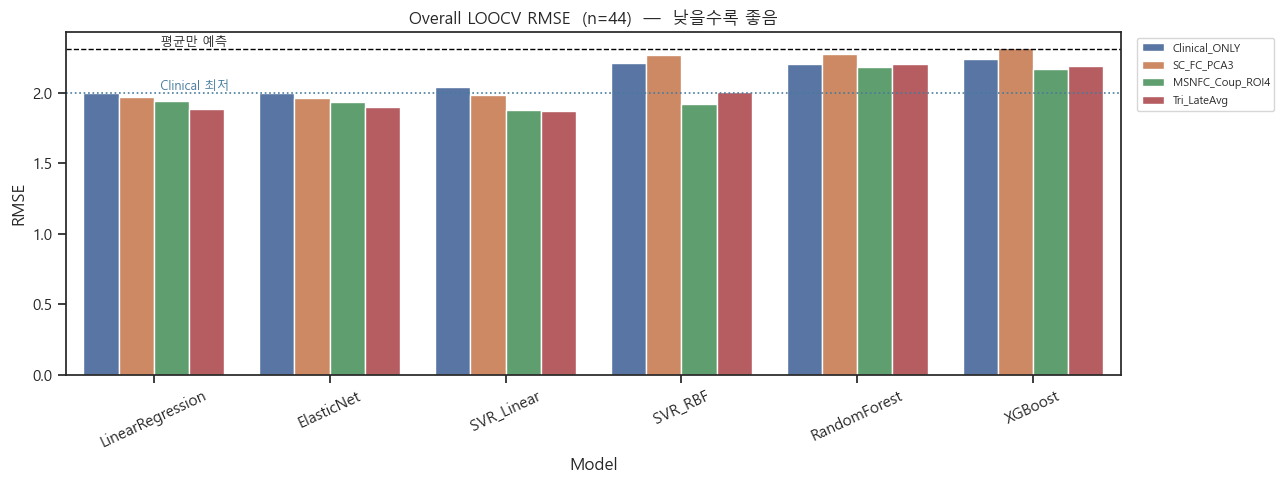

In [7]:
# ==========================================================
# 6. VISUALIZATION
# ==========================================================
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ov_long = res[res.Scope == 'Overall']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=ov_long, x='Model', y='RMSE', hue='Data Type', hue_order=DATA_TYPES, ax=ax)
ax.axhline(baseline_rmse, color='black', ls='--', lw=1)
ax.text(0.01, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
clin = ov_long.loc[ov_long['Data Type'] == 'Clinical_ONLY', 'RMSE'].min()
ax.axhline(clin, color='#457B9D', ls=':', lw=1.2)
ax.text(0.01, clin, ' Clinical 최저', va='bottom', fontsize=9, color='#457B9D')
ax.set_title('Overall LOOCV RMSE  (n=44)  —  낮을수록 좋음')
ax.tick_params(axis='x', rotation=25)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 7. 하이퍼파라미터 안정성
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{dt} / {name}] 고유 {len(vc)}개, 최빈 {share:.0%}{flag}")

[Clinical_ONLY / LinearRegression] 고유 1개, 최빈 100%
[Clinical_ONLY / ElasticNet] 고유 1개, 최빈 100%
[Clinical_ONLY / SVR_Linear] 고유 12개, 최빈 43%   <-- 불안정
[Clinical_ONLY / SVR_RBF] 고유 7개, 최빈 84%
[Clinical_ONLY / RandomForest] 고유 5개, 최빈 61%
[Clinical_ONLY / XGBoost] 고유 4개, 최빈 86%
[SC_FC_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[SC_FC_PCA3 / ElasticNet] 고유 6개, 최빈 75%
[SC_FC_PCA3 / SVR_Linear] 고유 7개, 최빈 66%
[SC_FC_PCA3 / SVR_RBF] 고유 14개, 최빈 41%   <-- 불안정
[SC_FC_PCA3 / RandomForest] 고유 10개, 최빈 36%   <-- 불안정
[SC_FC_PCA3 / XGBoost] 고유 6개, 최빈 43%   <-- 불안정
[MSNFC_Coup_ROI4 / LinearRegression] 고유 1개, 최빈 100%
[MSNFC_Coup_ROI4 / ElasticNet] 고유 7개, 최빈 39%   <-- 불안정
[MSNFC_Coup_ROI4 / SVR_Linear] 고유 8개, 최빈 75%
[MSNFC_Coup_ROI4 / SVR_RBF] 고유 5개, 최빈 86%
[MSNFC_Coup_ROI4 / RandomForest] 고유 7개, 최빈 57%
[MSNFC_Coup_ROI4 / XGBoost] 고유 6개, 최빈 77%
[Tri_LateAvg / LinearRegression] 고유 1개, 최빈 100%
[Tri_LateAvg / ElasticNet] 고유 1개, 최빈 100%
[Tri_LateAvg / SVR_Linear] 고유 1개, 최빈 100%
[Tri_LateAvg / SVR_RBF] 고유 1개, 최빈 100

## 결과 읽는 법

1. **평균이 둘 다보다 나은가**: `d_Late_vs_SCFC`와 `d_Late_vs_Coup`가 **둘 다** +면 두 모델의 오차가 서로 달랐다는 뜻이다.
   평균은 둘 중 나쁜 쪽보다는 항상 낫거나 같지만, 좋은 쪽보다 나은지는 두 모델이 얼마나 다르게 틀리는지에 달려 있다.
2. **붙이는 방법과 비교**: 같은 폴더의 `..._PCA3_plus_MSNFC_coupling_ROI` 노트북(피처를 붙인 것)과 나란히 본다.
3. **Active와 Sham**: 5번 셀과 10번 셀에서 군별 RMSE, r, R2를 나란히 본다. 모델은 44명 전체로 학습한 것이다.
4. **연결 기준**: pass가 주 분석이다. end에서 방향이 다르면 결론이 연결 기준에 달려 있다는 뜻이고, 그렇게 적는다.
5. **하지 말 것**: 다섯 방법과 두 연결 기준 중 좋게 나온 것만 골라 보고하는 것. 전부 보고한다.


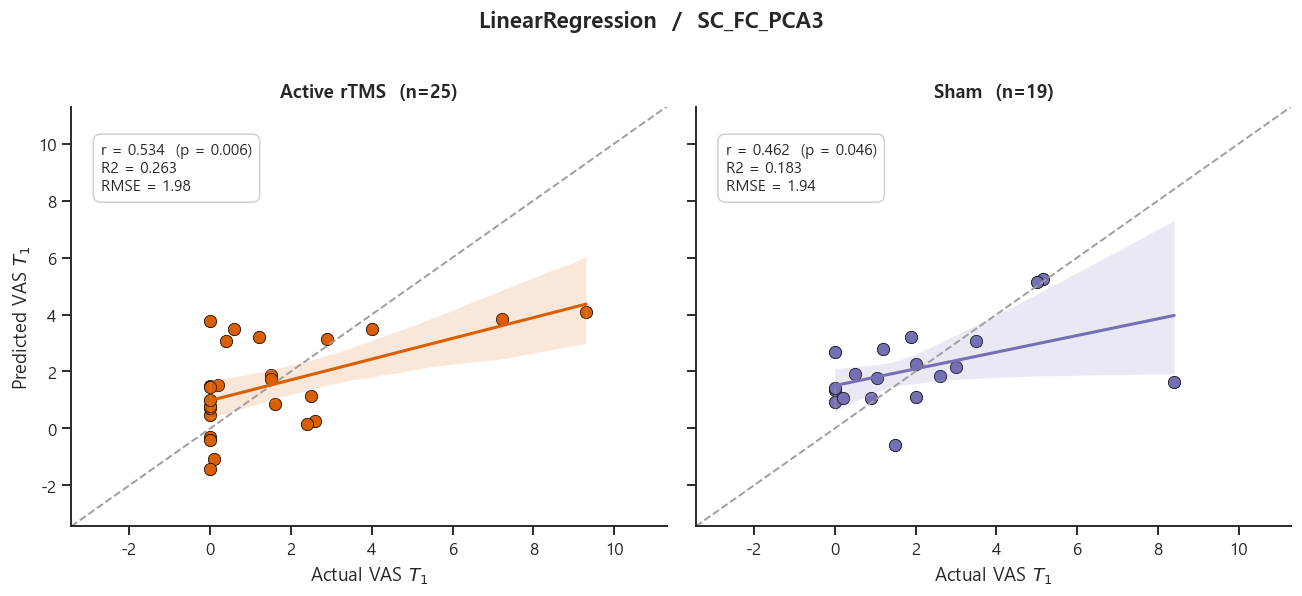

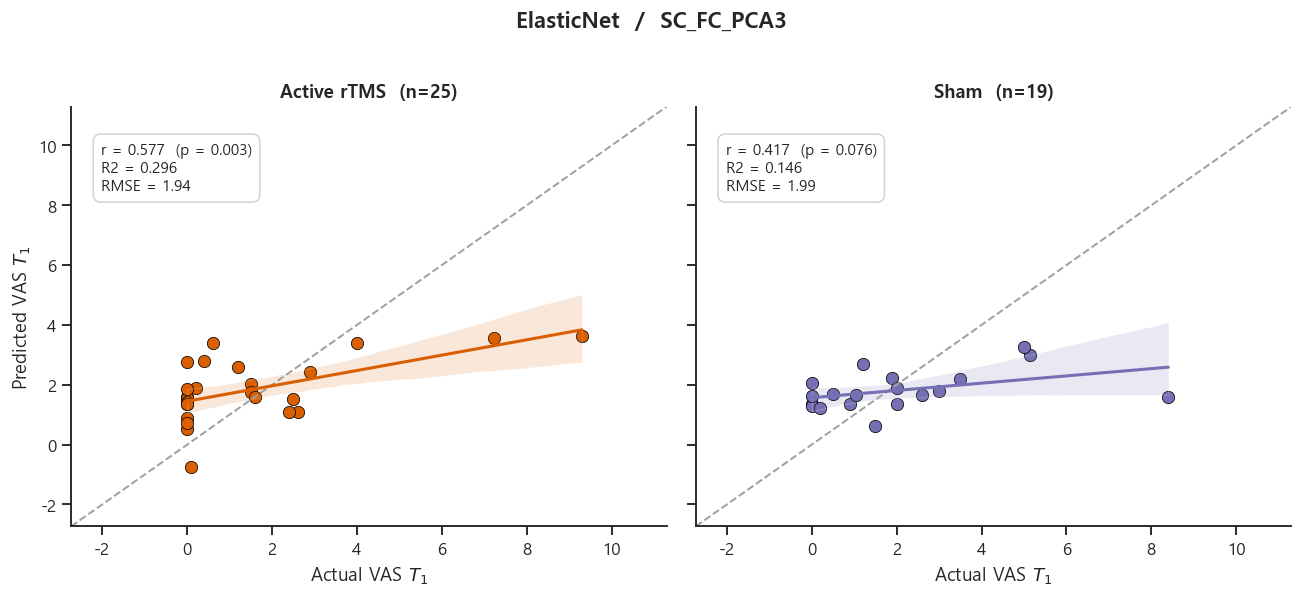

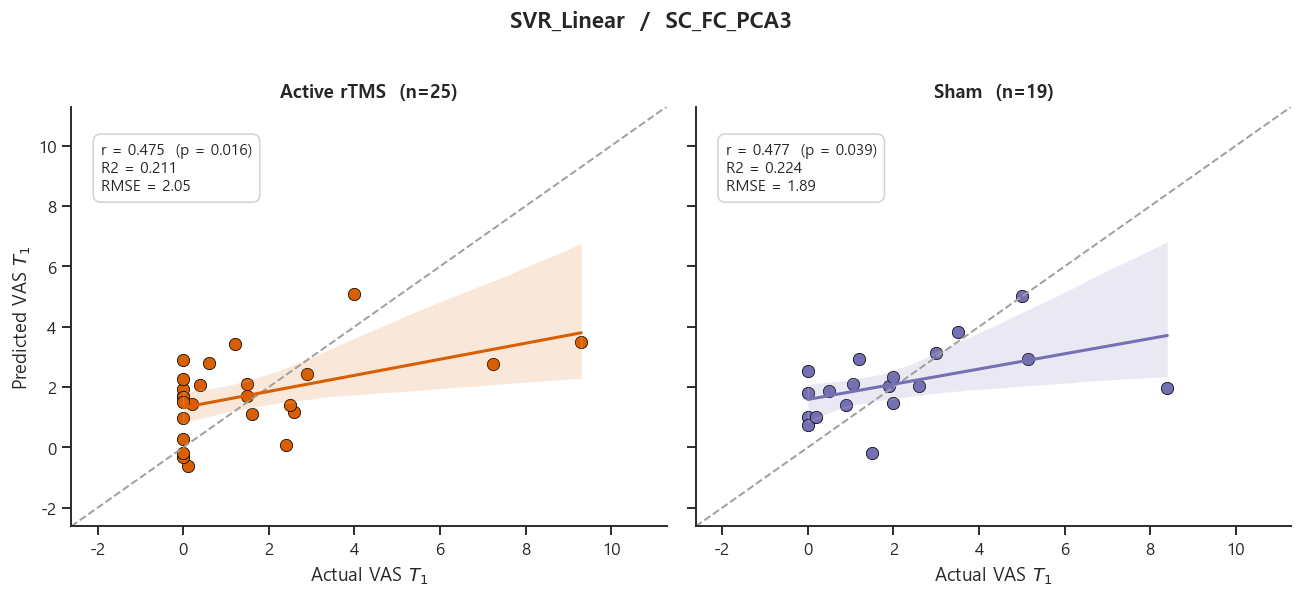

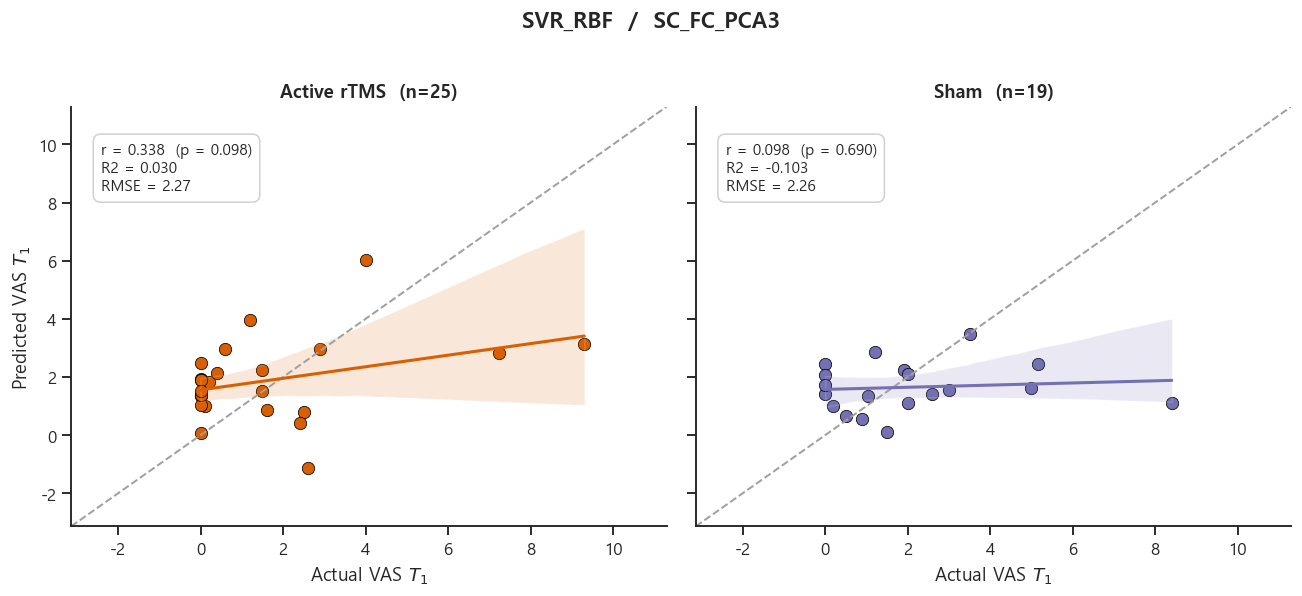

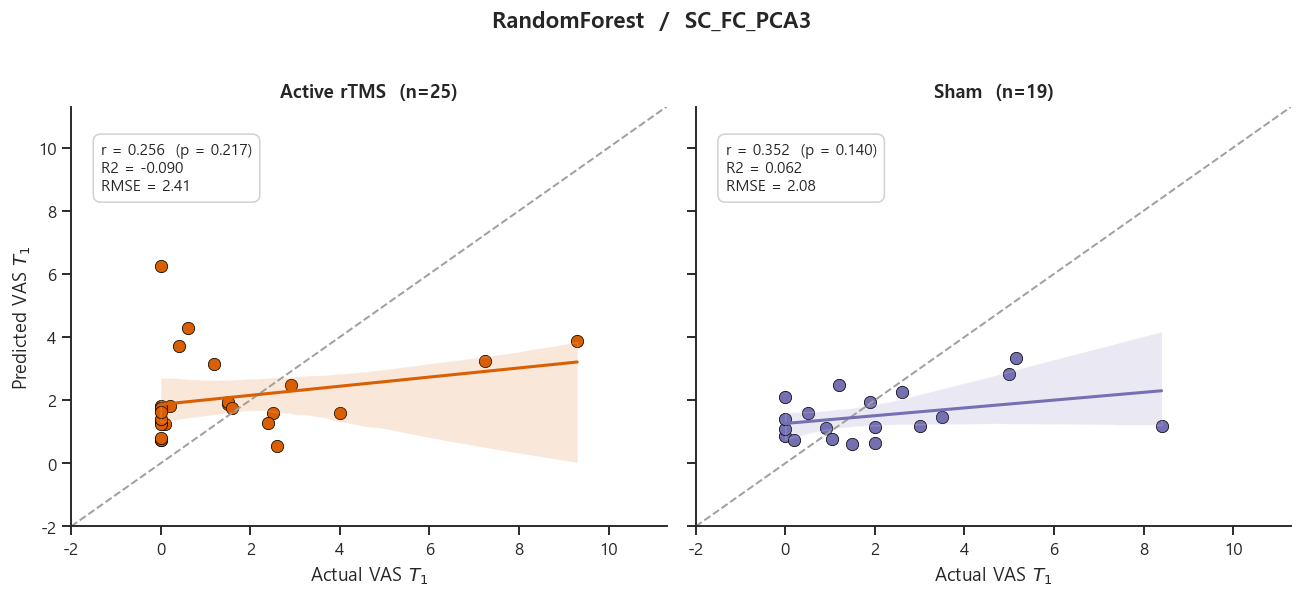

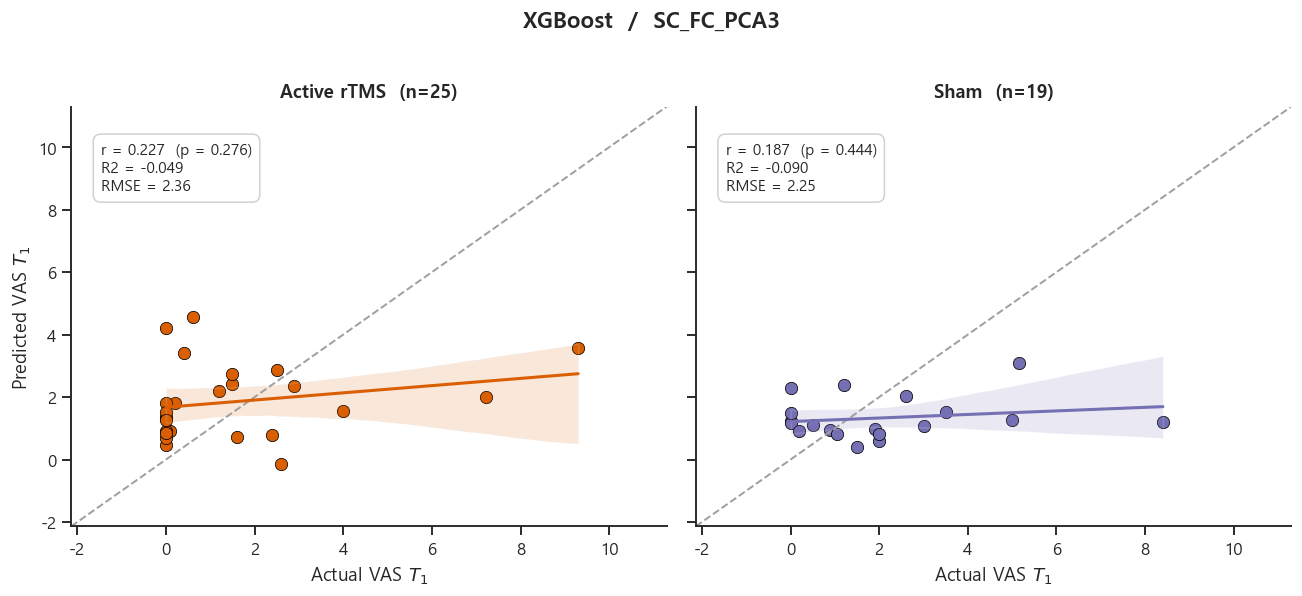

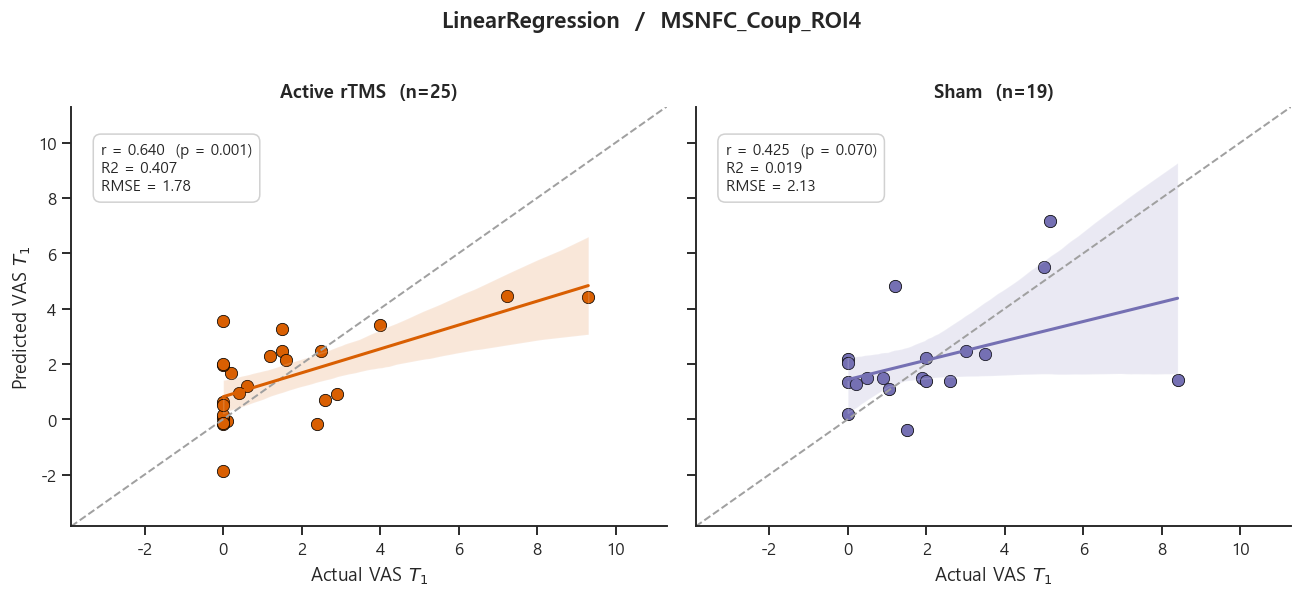

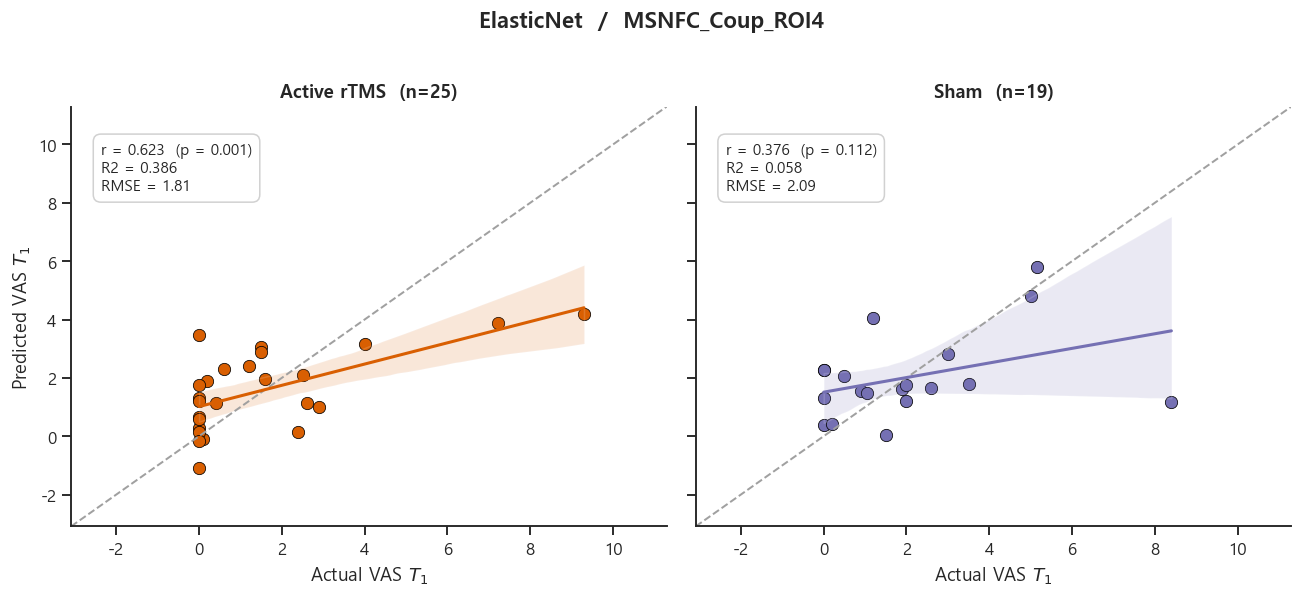

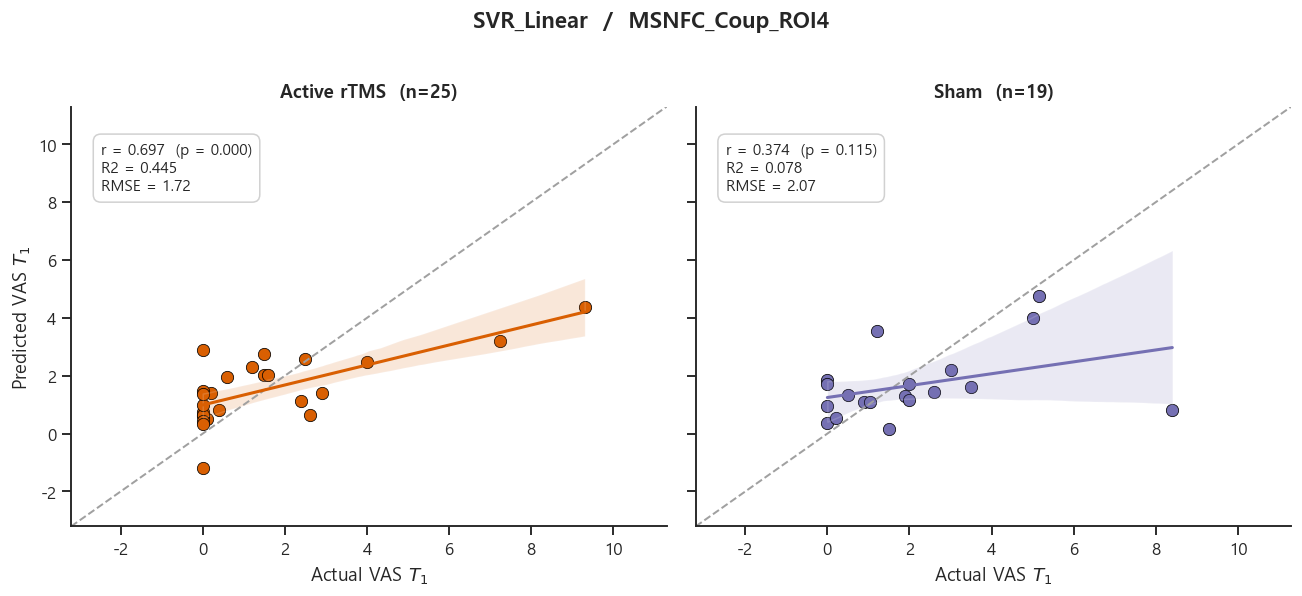

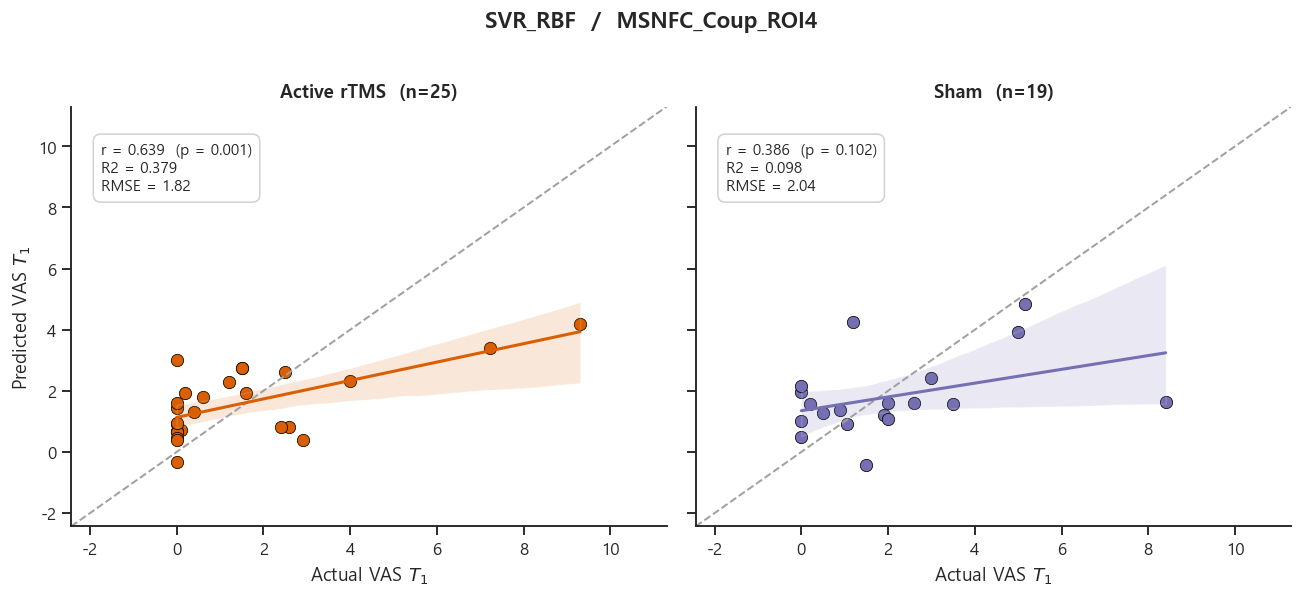

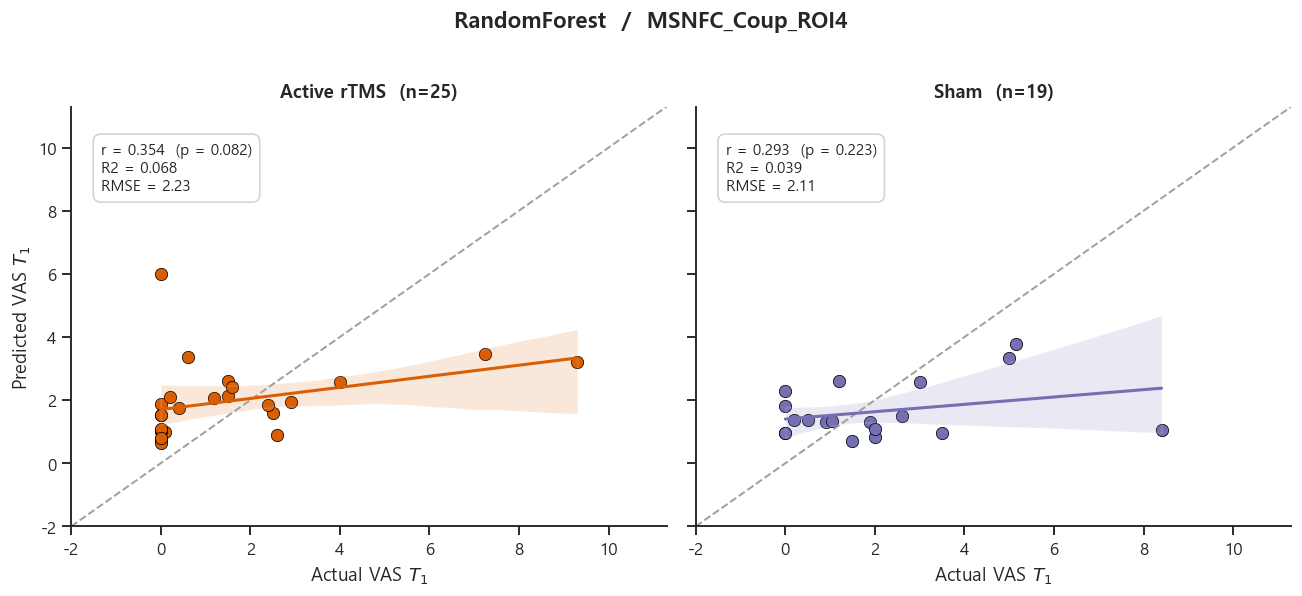

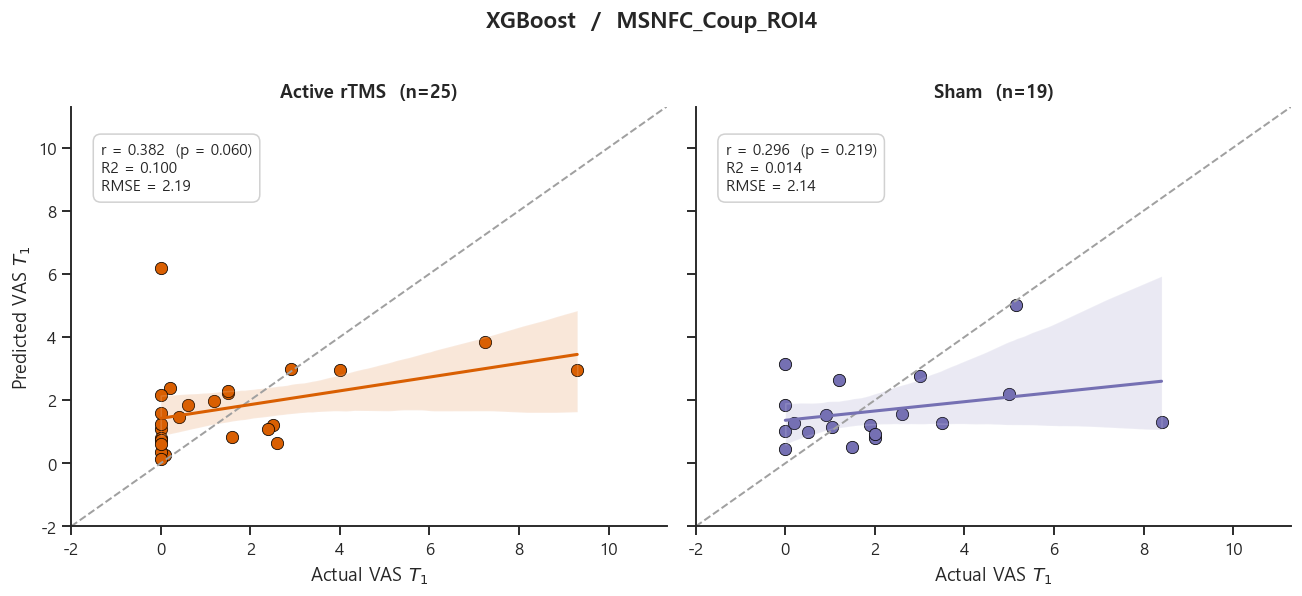

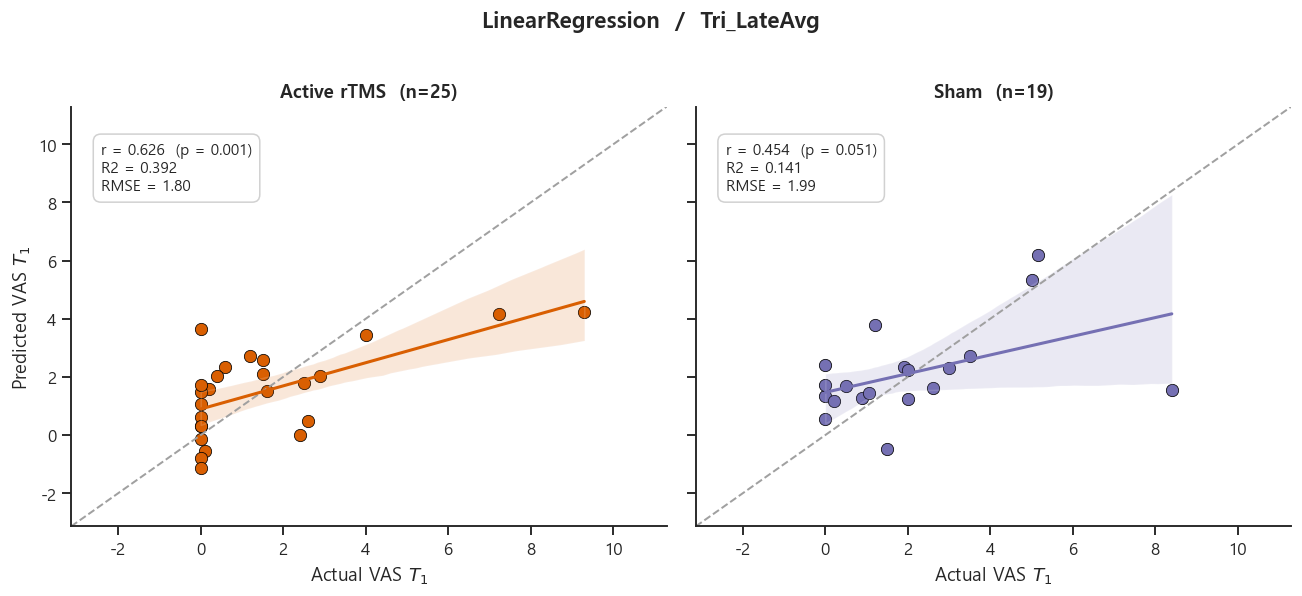

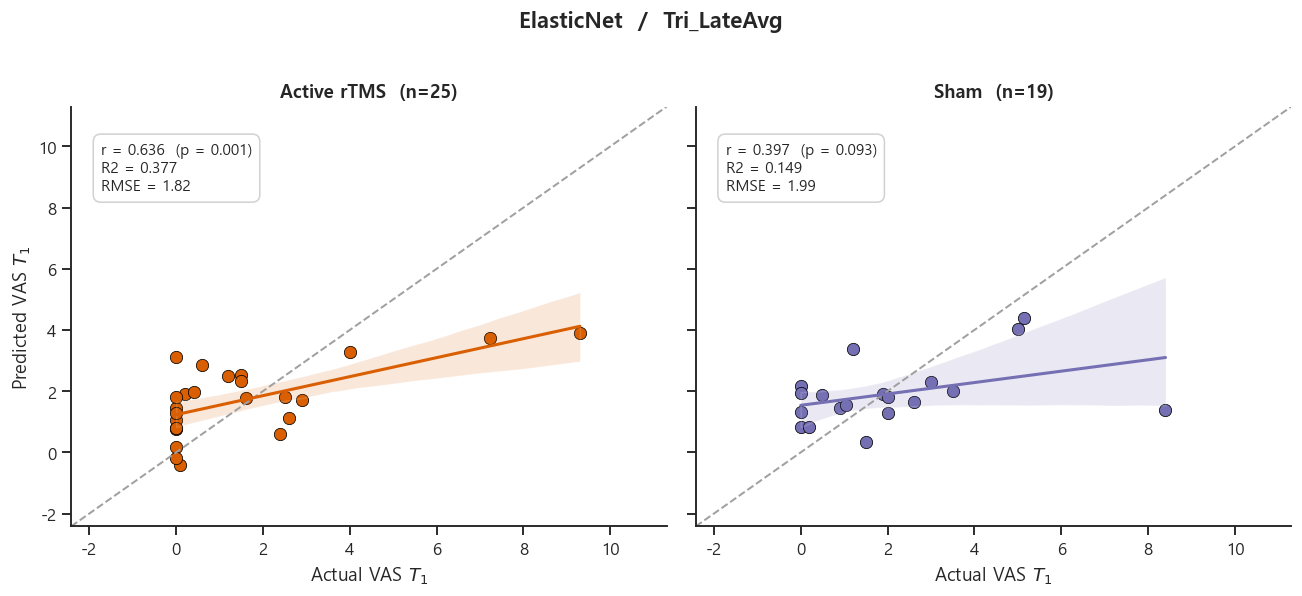

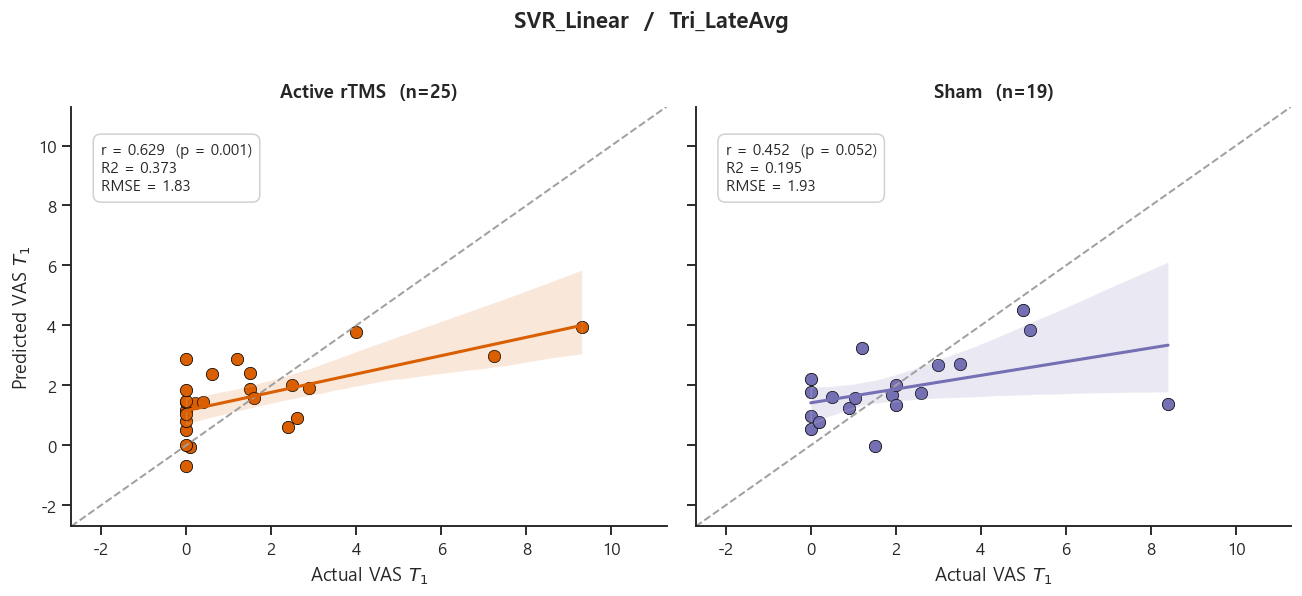

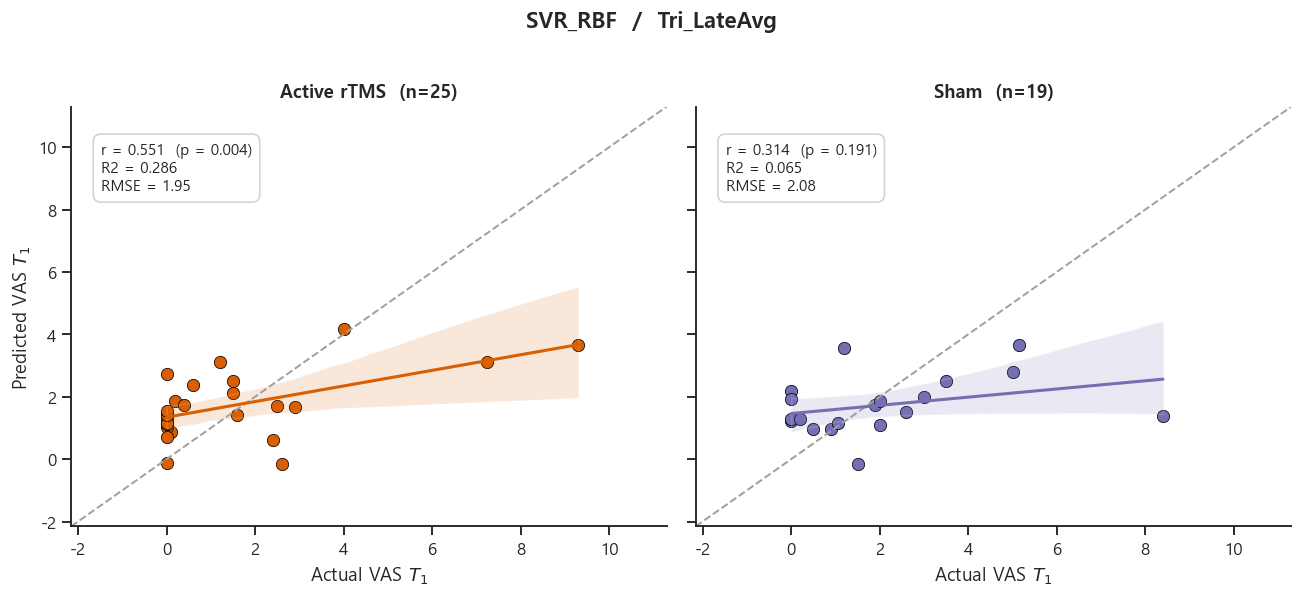

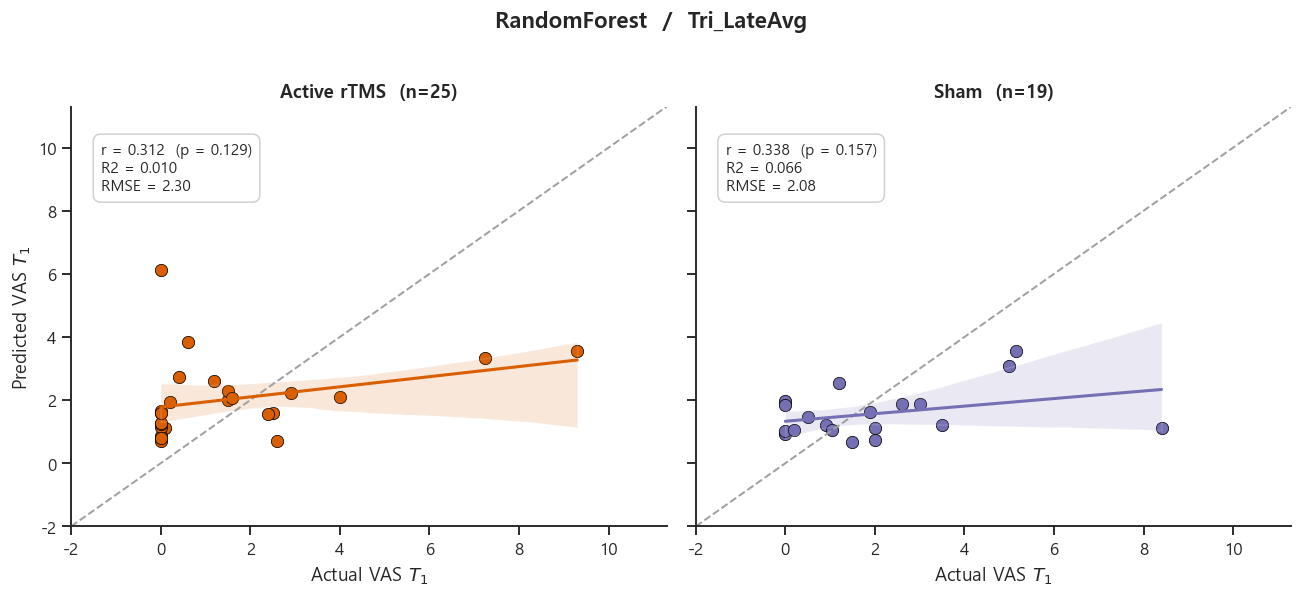

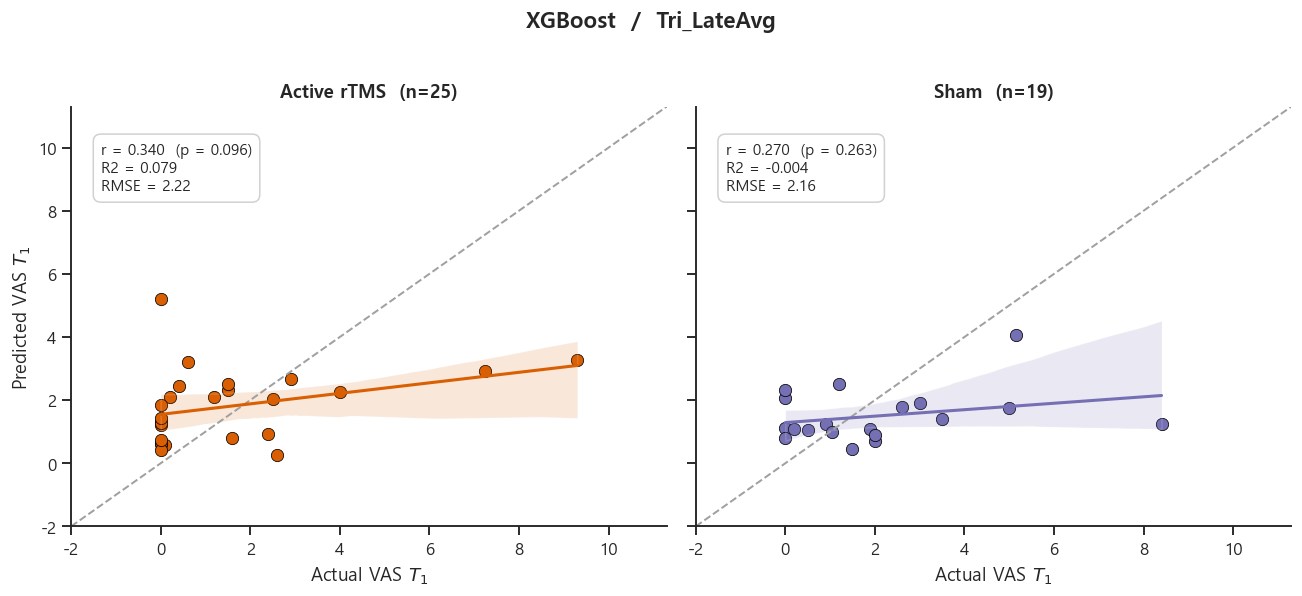

In [9]:
# ==========================================================
# 9. 산점도 — Active rTMS vs Sham 분리 (기존 멀티모달 노트북 8번 셀과 동일한 형식)
#    LOOCV 예측은 44명 전체로 학습한 것이고, 그림에서만 그룹을 나눠 본다.
# ==========================================================
PLOT_DATA_TYPES = ['SC_FC_PCA3', 'MSNFC_Coup_ROI4', 'Tri_LateAvg']   # 줄이려면 여기서 빼기
groups2 = ['Active rTMS', 'Sham']
palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
grp_full = np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')

for (dt, name), preds in predictions.items():
    if dt not in PLOT_DATA_TYPES:
        continue
    yp = np.array(preds)
    pdf = pd.DataFrame({'Actual': y_true, 'Predicted': yp, 'Group': grp_full})
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), sharex=True, sharey=True, dpi=110)
    lo = min(pdf['Actual'].min(), pdf['Predicted'].min()) - 2
    hi = max(pdf['Actual'].max(), pdf['Predicted'].max()) + 2
    for i, g in enumerate(groups2):
        ax = axes[i]
        sub = pdf[pdf['Group'] == g]
        r, pv = pearsonr(sub['Actual'], sub['Predicted'])
        ax.plot([lo, hi], [lo, hi], color='#A0A0A0', ls='--', lw=1.3)
        sns.scatterplot(data=sub, x='Actual', y='Predicted', color=palette[g], s=65,
                        edgecolor='black', linewidth=0.5, ax=ax)
        sns.regplot(data=sub, x='Actual', y='Predicted', ax=ax, scatter=False,
                    color=palette[g], line_kws={'linewidth': 2})
        ax.set_title(f'{g}  (n={len(sub)})', fontweight='bold')
        ax.text(0.05, 0.80,
                f"r = {r:.3f}  (p = {pv:.3f})\n"
                f"R2 = {r2_score(sub['Actual'], sub['Predicted']):.3f}\n"
                f"RMSE = {np.sqrt(np.mean((sub['Actual'] - sub['Predicted']) ** 2)):.2f}",
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#CCC', alpha=0.9))
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel('Actual VAS $T_1$')
        if i == 0:
            ax.set_ylabel('Predicted VAS $T_1$')
    fig.suptitle(f'{name}  /  {dt}', fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [10]:
# ==========================================================
# 10. 산점도 결과 표 — 9번 셀의 r / R2 / RMSE 를 모델별로 정리
#     (그림에 찍힌 값과 같은 숫자다. 눈으로 비교하기 어려우니 표로 모은다)
# ==========================================================
rows_sc = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for g, m in [('Active', group == 'Active'), ('Sham', group == 'Sham')]:
        r, pv = pearsonr(y_true[m], yp[m])
        rows_sc.append({'Data Type': dt, 'Model': name, 'Group': g, 'n': int(m.sum()),
                        'RMSE': np.sqrt(np.mean((y_true[m] - yp[m]) ** 2)),
                        'R2': r2_score(y_true[m], yp[m]), 'r': r, 'p': pv})

sc = pd.DataFrame(rows_sc)
sc['Data Type'] = pd.Categorical(sc['Data Type'], DATA_TYPES)
sc['Model'] = pd.Categorical(sc['Model'], list(models))

# --- 넓은 표: 행 = 피처셋 x 모델, 열 = Active/Sham x 지표 ---
wide = sc.pivot_table(index=['Data Type', 'Model'], columns='Group',
                      values=['RMSE', 'R2', 'r', 'p'], observed=True)
wide = wide.swaplevel(axis=1).sort_index(axis=1, level=0)
wide = wide[[('Active', k) for k in ['RMSE', 'R2', 'r', 'p']] +
            [('Sham', k) for k in ['RMSE', 'R2', 'r', 'p']]]

print(f"Active {int((group == 'Active').sum())}명 / Sham {int((group == 'Sham').sum())}명")
print("  RMSE는 낮을수록, r은 높을수록 좋다.")
print("  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).\n")
display(wide.round(3))

# --- 좁은 표: RMSE와 r만, 두 군을 나란히 ---
print("\n========== RMSE / r 만 추려보기 ==========")
slim = wide[[('Active', 'RMSE'), ('Sham', 'RMSE'), ('Active', 'r'), ('Sham', 'r')]].copy()
slim.columns = ['RMSE_Active', 'RMSE_Sham', 'r_Active', 'r_Sham']
slim['RMSE_diff'] = slim['RMSE_Active'] - slim['RMSE_Sham']   # 음수면 Active에서 오차가 작음
display(slim.round(3))

# --- 군별로 가장 좋았던 조합 ---
print("\n========== 군별 RMSE 상위 5 ==========")
for g in ['Active', 'Sham']:
    print(f'\n[{g}]')
    display(sc[sc.Group == g].sort_values('RMSE')[['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
            .round(3).head(5).reset_index(drop=True))

Active 25명 / Sham 19명
  RMSE는 낮을수록, r은 높을수록 좋다.
  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).



Group                            Active                        Sham         \
                                   RMSE     R2      r      p   RMSE     R2   
Data Type       Model                                                        
Clinical_ONLY   LinearRegression  2.004  0.246  0.507  0.010  1.989  0.145   
                ElasticNet        2.003  0.247  0.507  0.010  1.988  0.146   
                SVR_Linear        2.055  0.207  0.475  0.016  2.022  0.117   
                SVR_RBF           2.291  0.015  0.358  0.079  2.095  0.052   
                RandomForest      2.261  0.040  0.356  0.081  2.118  0.031   
                XGBoost           2.341 -0.029  0.319  0.120  2.089  0.058   
SC_FC_PCA3      LinearRegression  1.981  0.263  0.534  0.006  1.944  0.183   
                ElasticNet        1.936  0.296  0.577  0.003  1.988  0.146   
                SVR_Linear        2.050  0.211  0.475  0.016  1.895  0.224   
                SVR_RBF           2.273  0.030  0.338  0.098  2.259 -0.103   
                RandomForest      2.409 -0.090  0.256  0.217  2.084  0.062   
                XGBoost           2.363 -0.049  0.227  0.276  2.246 -0.090   
MSNFC_Coup_ROI4 LinearRegression  1.777  0.407  0.640  0.001  2.131  0.019   
                ElasticNet        1.808  0.386  0.623  0.001  2.088  0.058   
                SVR_Linear        1.719  0.445  0.697  0.000  2.066  0.078   
                SVR_RBF           1.818  0.379  0.639  0.001  2.043  0.098   
                RandomForest      2.228  0.068  0.354  0.082  2.109  0.039   
                XGBoost           2.189  0.100  0.382  0.060  2.136  0.014   
Tri_LateAvg     LinearRegression  1.799  0.392  0.626  0.001  1.995  0.141   
                ElasticNet        1.822  0.377  0.636  0.001  1.985  0.149   
                SVR_Linear        1.827  0.373  0.629  0.001  1.930  0.195   
                SVR_RBF           1.950  0.286  0.551  0.004  2.080  0.065   
                RandomForest      2.297  0.010  0.312  0.129  2.079  0.066   
                XGBoost           2.215  0.079  0.340  0.096  2.156 -0.004   

Group                                           
                                      r      p  
Data Type       Model                           
Clinical_ONLY   LinearRegression  0.402  0.088  
                ElasticNet        0.402  0.088  
                SVR_Linear        0.400  0.090  
                SVR_RBF           0.329  0.170  
                RandomForest      0.302  0.209  
                XGBoost           0.307  0.202  
SC_FC_PCA3      LinearRegression  0.462  0.046  
                ElasticNet        0.417  0.076  
                SVR_Linear        0.477  0.039  
                SVR_RBF           0.098  0.690  
                RandomForest      0.352  0.140  
                XGBoost           0.187  0.444  
MSNFC_Coup_ROI4 LinearRegression  0.425  0.070  
                ElasticNet        0.376  0.112  
                SVR_Linear        0.374  0.115  
                SVR_RBF           0.386  0.102  
                RandomForest      0.293  0.223  
                XGBoost           0.296  0.219  
Tri_LateAvg     LinearRegression  0.454  0.051  
                ElasticNet        0.397  0.093  
                SVR_Linear        0.452  0.052  
                SVR_RBF           0.314  0.191  
                RandomForest      0.338  0.157  
                XGBoost           0.270  0.263


========== RMSE / r 만 추려보기 ==========


RMSE_Active  RMSE_Sham  r_Active  r_Sham  \
Data Type       Model                                                        
Clinical_ONLY   LinearRegression        2.004      1.989     0.507   0.402   
                ElasticNet              2.003      1.988     0.507   0.402   
                SVR_Linear              2.055      2.022     0.475   0.400   
                SVR_RBF                 2.291      2.095     0.358   0.329   
                RandomForest            2.261      2.118     0.356   0.302   
                XGBoost                 2.341      2.089     0.319   0.307   
SC_FC_PCA3      LinearRegression        1.981      1.944     0.534   0.462   
                ElasticNet              1.936      1.988     0.577   0.417   
                SVR_Linear              2.050      1.895     0.475   0.477   
                SVR_RBF                 2.273      2.259     0.338   0.098   
                RandomForest            2.409      2.084     0.256   0.352   
                XGBoost                 2.363      2.246     0.227   0.187   
MSNFC_Coup_ROI4 LinearRegression        1.777      2.131     0.640   0.425   
                ElasticNet              1.808      2.088     0.623   0.376   
                SVR_Linear              1.719      2.066     0.697   0.374   
                SVR_RBF                 1.818      2.043     0.639   0.386   
                RandomForest            2.228      2.109     0.354   0.293   
                XGBoost                 2.189      2.136     0.382   0.296   
Tri_LateAvg     LinearRegression        1.799      1.995     0.626   0.454   
                ElasticNet              1.822      1.985     0.636   0.397   
                SVR_Linear              1.827      1.930     0.629   0.452   
                SVR_RBF                 1.950      2.080     0.551   0.314   
                RandomForest            2.297      2.079     0.312   0.338   
                XGBoost                 2.215      2.156     0.340   0.270   

                                  RMSE_diff  
Data Type       Model                        
Clinical_ONLY   LinearRegression      0.015  
                ElasticNet            0.015  
                SVR_Linear            0.033  
                SVR_RBF               0.196  
                RandomForest          0.143  
                XGBoost               0.252  
SC_FC_PCA3      LinearRegression      0.037  
                ElasticNet           -0.052  
                SVR_Linear            0.156  
                SVR_RBF               0.014  
                RandomForest          0.325  
                XGBoost               0.118  
MSNFC_Coup_ROI4 LinearRegression     -0.355  
                ElasticNet           -0.280  
                SVR_Linear           -0.347  
                SVR_RBF              -0.225  
                RandomForest          0.119  
                XGBoost               0.053  
Tri_LateAvg     LinearRegression     -0.195  
                ElasticNet           -0.163  
                SVR_Linear           -0.103  
                SVR_RBF              -0.130  
                RandomForest          0.218  
                XGBoost               0.060


========== 군별 RMSE 상위 5 ==========

[Active]


,Data Type,Model,RMSE,R2,r,p
0,MSNFC_Coup_ROI4,SVR_Linear,1.719,0.445,0.697,0.000
1,MSNFC_Coup_ROI4,LinearRegression,1.777,0.407,0.640,0.001
2,Tri_LateAvg,LinearRegression,1.799,0.392,0.626,0.001
3,MSNFC_Coup_ROI4,ElasticNet,1.808,0.386,0.623,0.001
4,MSNFC_Coup_ROI4,SVR_RBF,1.818,0.379,0.639,0.001



[Sham]


,Data Type,Model,RMSE,R2,r,p
0,SC_FC_PCA3,SVR_Linear,1.895,0.224,0.477,0.039
1,Tri_LateAvg,SVR_Linear,1.930,0.195,0.452,0.052
2,SC_FC_PCA3,LinearRegression,1.944,0.183,0.462,0.046
3,Tri_LateAvg,ElasticNet,1.985,0.149,0.397,0.093
4,SC_FC_PCA3,ElasticNet,1.988,0.146,0.417,0.076
